# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [1]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [2]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [3]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [4]:
coffee_df.shape


(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [5]:

coffee_df.dtypes

transaction_date               str
transaction_time               str
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group                  str
product_category               str
product_type                   str
current_wholesale_price    float64
customer_since                 str
customer_birth_year        float64
customer_generation            str
dtype: object

> 👉 **Write Your Findings Here**: 
-- -

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [6]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])
coffee_df.dtypes


transaction_date           datetime64[us]
transaction_time                      str
customer_id                       float64
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                         str
product_category                      str
product_type                          str
current_wholesale_price           float64
customer_since             datetime64[us]
customer_birth_year               float64
customer_generation                   str
dtype: object

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [7]:
coffee_df.isna().mean() * 100


transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [8]:
# how many duplicates we have
coffee_df.duplicated().sum()


np.int64(149)

In [10]:
# Remove the duplicates and check if the total duplicates is 0 now
coffee_df = coffee_df.drop_duplicates()
coffee_df.duplicated().sum()

np.int64(0)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [11]:
# unique values in product group
coffee_df['product_group'].unique()


<ArrowStringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [12]:
# unique values in product category
coffee_df['product_category'].unique()


<ArrowStringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [13]:
# unique values in product type
coffee_df['product_type'].unique()


<ArrowStringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [14]:
# unique values in customer_generation
coffee_df['customer_generation'].unique()


<ArrowStringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',                   nan]
Length: 6, dtype: str

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [15]:
coffee_df.describe()


,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.687731,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000
std,NaN,3247.554091,0.543316,4.441833,2.686402,2.204466,NaN,15.088333


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [16]:
coffee_df['total_wholesale_amount'] = coffee_df['current_wholesale_price'] * coffee_df['quantity']
coffee_df[['current_wholesale_price', 'quantity', 'total_wholesale_amount']].head()


,current_wholesale_price,quantity,total_wholesale_amount
0,0.63,1,0.63
1,0.63,1,0.63
2,0.63,2,1.26
3,0.63,1,0.63
4,0.63,2,1.26


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [17]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df[['line_item_amount', 'total_wholesale_amount', 'profit']].head()


,line_item_amount,total_wholesale_amount,profit
0,2.5,0.63,1.87
1,2.5,0.63,1.87
2,5.0,1.26,3.74
3,2.5,0.63,1.87
4,5.0,1.26,3.74


##### 13.❓Find the highest sale price in the dataset.

In [19]:
highest_sale_price = coffee_df['line_item_amount'].max()
highest_sale_price

np.float64(360.0)

##### 14.❓Find the largest amount of profit.

In [20]:
largest_profit = coffee_df['profit'].max()
largest_profit

np.float64(72.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [21]:
mean_profit = coffee_df['profit'].mean()
mean_profit

np.float64(2.9367379636144335)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [22]:
mean_amount = coffee_df['line_item_amount'].mean()
above_mean_count = (coffee_df['line_item_amount'] > mean_amount).sum()


##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [23]:
coffee_df['profit_ratio'] = coffee_df['profit'] / coffee_df['total_wholesale_amount']
coffee_df[['profit', 'total_wholesale_amount', 'profit_ratio']].head()


,profit,total_wholesale_amount,profit_ratio
0,1.87,0.63,2.968254
1,1.87,0.63,2.968254
2,3.74,1.26,2.968254
3,1.87,0.63,2.968254
4,3.74,1.26,2.968254


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [25]:
double_profit_count = (coffee_df['profit_ratio'] >= 2).sum()
double_profit_count

np.int64(37250)

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [26]:
bean_mask = coffee_df['product_type'].str.contains('bean', case=False, na=False)
bean_count = bean_mask.sum()
coffee_df[bean_mask]['product_type'].unique()

<ArrowStringArray>
[    'Organic Beans',     'Gourmet Beans', 'House blend Beans',
     'Premium Beans',       'Green beans',    'Espresso Beans']
Length: 6, dtype: str

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [27]:
coffee_df.sort_values('profit', ascending=False).head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49092,2019-04-17,09:55:47,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.00,NaT,NaN,NaN,288.00,72.00,0.250
49091,2019-04-17,09:05:20,8311.0,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.00,2017-03-27,1967.0,Gen X,288.00,72.00,0.250
49089,2019-04-17,10:41:11,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.00,NaT,NaN,NaN,288.00,72.00,0.250
49088,2019-04-17,11:18:31,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.00,NaT,NaN,NaN,288.00,72.00,0.250
49441,2019-04-09,09:04:04,NaN,6,72.0,12.0,Merchandise,Branded,Housewares,3.84,NaT,NaN,NaN,23.04,48.96,2.125


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [28]:
loss_transactions = coffee_df[coffee_df['profit'] < 0]
loss_transactions[['unit_price', 'quantity', 'line_item_amount', 'current_wholesale_price', 'total_wholesale_amount', 'profit']]


,unit_price,quantity,line_item_amount,current_wholesale_price,total_wholesale_amount,profit
37654,3.75,1,1.0,2.44,2.44,-1.44
37656,3.75,1,1.0,2.44,2.44,-1.44
37658,3.75,1,1.0,2.44,2.44,-1.44
37659,3.75,1,1.0,2.44,2.44,-1.44
37662,3.75,1,1.0,2.44,2.44,-1.44
...,...,...,...,...,...,...
45386,2.65,3,0.0,2.11,6.33,-6.33
45390,2.65,1,0.0,2.11,2.11,-2.11
45395,2.65,3,0.0,2.11,6.33,-6.33
46267,12.00,1,12.0,18.00,18.00,-6.00


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
- 

##### 22.❓Correct the line item amount column with the correct values

In [29]:
coffee_df['line_item_amount'] = coffee_df['unit_price'] * coffee_df['quantity']
coffee_df[['unit_price', 'quantity', 'line_item_amount']].head()


,unit_price,quantity,line_item_amount
0,2.5,1,2.5
1,2.5,1,2.5
2,2.5,2,5.0
3,2.5,1,2.5
4,2.5,2,5.0


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [30]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df['profit_ratio'] = coffee_df['profit'] / coffee_df['total_wholesale_amount']
coffee_df[['line_item_amount', 'total_wholesale_amount', 'profit']].head()


,line_item_amount,total_wholesale_amount,profit
0,2.5,0.63,1.87
1,2.5,0.63,1.87
2,5.0,1.26,3.74
3,2.5,0.63,1.87
4,5.0,1.26,3.74


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [31]:
loss_transactions = coffee_df[coffee_df['profit'] < 0]
loss_transactions[['unit_price', 'quantity', 'line_item_amount', 'current_wholesale_price', 'total_wholesale_amount', 'profit']]

,unit_price,quantity,line_item_amount,current_wholesale_price,total_wholesale_amount,profit
46267,12.0,1,12.0,18.0,18.0,-6.0
46268,12.0,1,12.0,18.0,18.0,-6.0


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [32]:
product_group_counts = coffee_df['product_group'].value_counts()
product_group_counts


product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

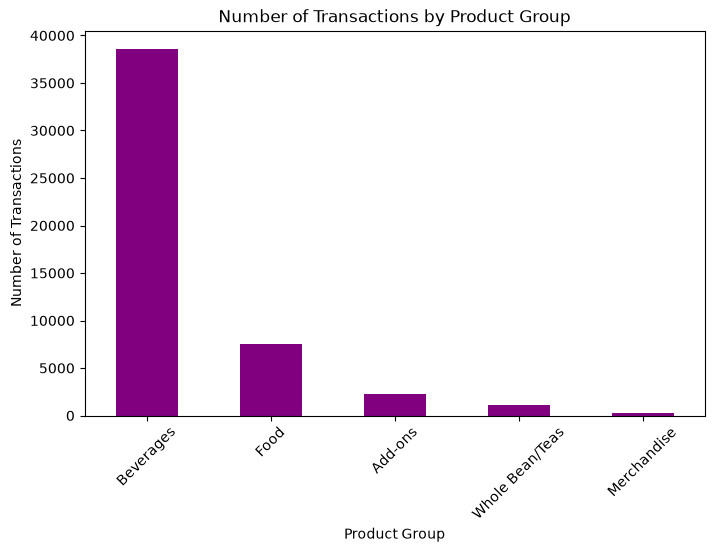

In [34]:
plt.figure(figsize=(8, 5))
product_group_counts.plot(kind='bar', color='purple')
plt.title('Number of Transactions by Product Group')
plt.xlabel('Product Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()


##### 27.❓Can you calculate the median profit for each product type?

In [35]:
median_profit_by_type = coffee_df.groupby('product_type')['profit'].median().sort_values(ascending=False)
median_profit_by_type


product_type
Clothing                 19.04
Housewares                9.52
Premium Beans             9.00
Gourmet Beans             4.20
Premium brewed coffee     3.92
Brewed Green tea          3.74
Brewed herbal tea         3.74
Brewed Black tea          3.74
Brewed Chai tea           3.74
House blend Beans         3.60
Organic Beans             3.60
Organic brewed coffee     3.52
Barista Espresso          3.40
Gourmet brewed coffee     3.20
Espresso Beans            2.95
Drinking Chocolate        2.67
Drip coffee               2.40
Green beans               2.00
Chai tea                  1.90
Green tea                 1.85
Black tea                 1.79
Herbal tea                1.79
Hot chocolate             1.74
Sugar free syrup          1.52
Regular syrup             1.52
Organic Chocolate         1.52
Pastry                    1.31
Biscotti                  1.22
Scone                     1.14
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [36]:
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day_name()
coffee_df[['transaction_date', 'transaction_day']].head()


,transaction_date,transaction_day
0,2019-04-01,Monday
1,2019-04-01,Monday
2,2019-04-01,Monday
3,2019-04-01,Monday
4,2019-04-01,Monday


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [37]:
day_revenue = coffee_df.groupby('transaction_day')['line_item_amount'].sum().sort_values(ascending=False)
day_revenue


transaction_day
Monday       39563.74
Wednesday    34374.03
Tuesday      32371.81
Friday       32304.55
Saturday     32138.85
Thursday     31902.82
Sunday       31014.75
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

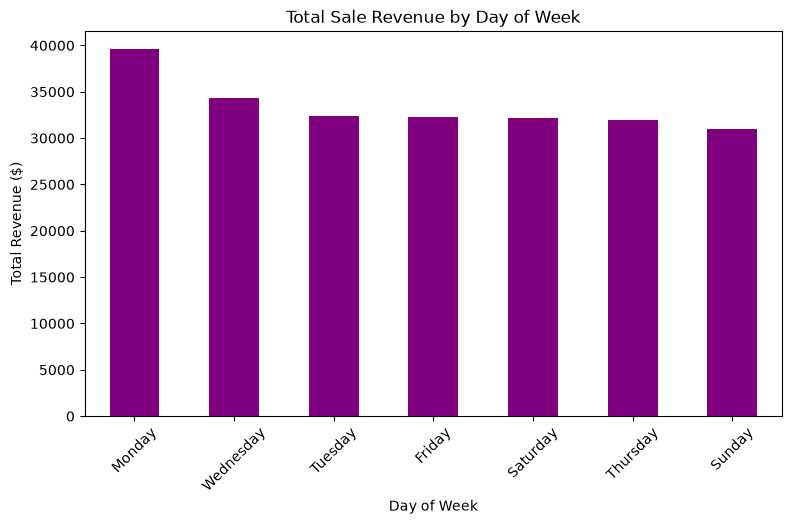

In [40]:
plt.figure(figsize=(9, 5))
day_revenue.plot(kind='bar', color='purple')
plt.title('Total Sale Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()


##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [41]:
generation_spend = coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending=False)
generation_spend


customer_generation
Baby Boomers           27295.04
Gen X                  26739.61
Older Millennials      25166.90
Gen Z                  19716.40
Younger Millennials    15414.78
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

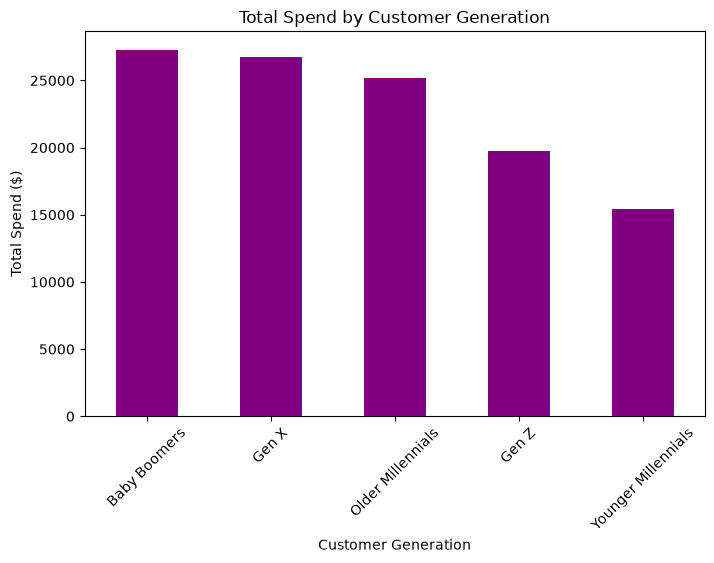

In [42]:
plt.figure(figsize=(8, 5))
generation_spend.plot(kind='bar', color='purple')
plt.title('Total Spend by Customer Generation')
plt.xlabel('Customer Generation')
plt.ylabel('Total Spend ($)')
plt.xticks(rotation=45)
plt.show()


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [43]:
top5_profit_by_type = coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)
top5_profit_by_type


product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

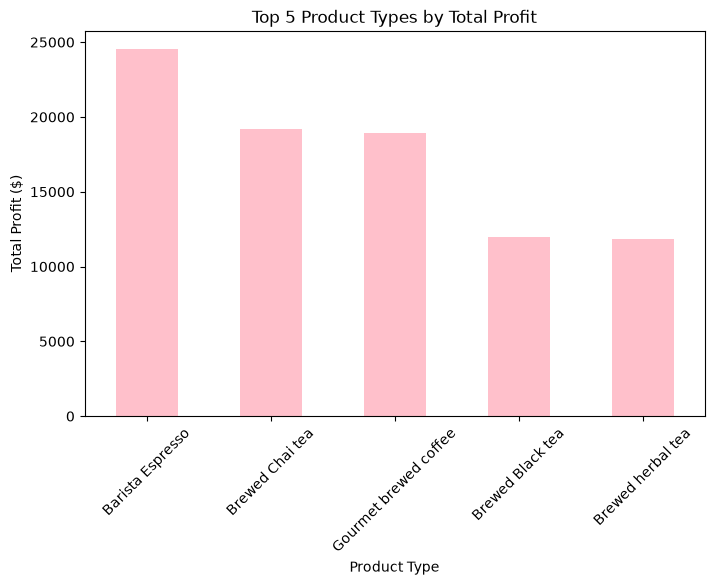

In [47]:
plt.figure(figsize=(8, 5))
top5_profit_by_type.plot(kind='bar', color='pink')
plt.title('Top 5 Product Types by Total Profit')
plt.xlabel('Product Type')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)
plt.show()


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [48]:
profit_ratio_by_gen = coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending=False)
profit_ratio_by_gen


customer_generation
Baby Boomers           3.311118
Gen Z                  3.301270
Older Millennials      3.240118
Gen X                  3.229654
Younger Millennials    3.201551
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

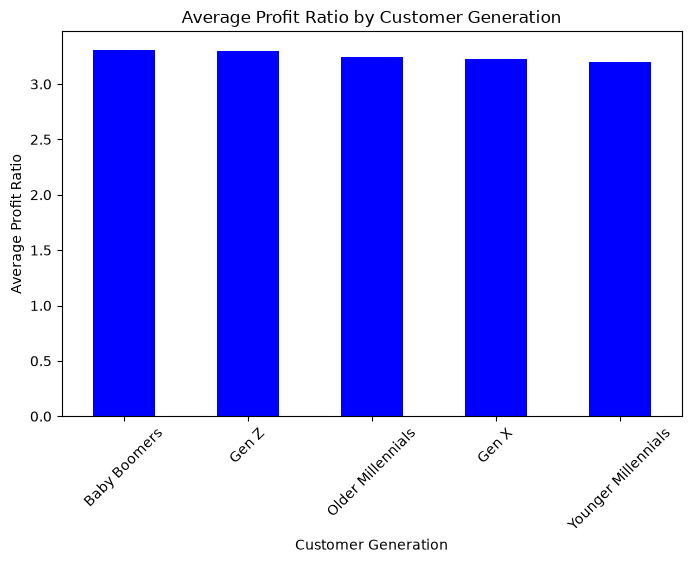

In [51]:
plt.figure(figsize=(8, 5))
profit_ratio_by_gen.plot(kind='bar', color='blue')
plt.title('Average Profit Ratio by Customer Generation')
plt.xlabel('Customer Generation')
plt.ylabel('Average Profit Ratio')
plt.xticks(rotation=45)
plt.show()




## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [52]:
# Extracting dates from transaction date
coffee_df['transaction_hour'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.hour
coffee_df[['transaction_time', 'transaction_hour']].head()


,transaction_time,transaction_hour
0,12:04:43,12
1,11:15:38,11
2,12:05:31,12
3,16:49:38,16
4,19:17:34,19


In [53]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time
def time_category(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Noon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# use apply to apply the time category into a new column called time_category
coffee_df['time_category'] = coffee_df['transaction_hour'].apply(time_category)
coffee_df[['transaction_hour', 'time_category']].head()


,transaction_hour,time_category
0,12,Noon
1,11,Morning
2,12,Noon
3,16,Noon
4,19,Evening


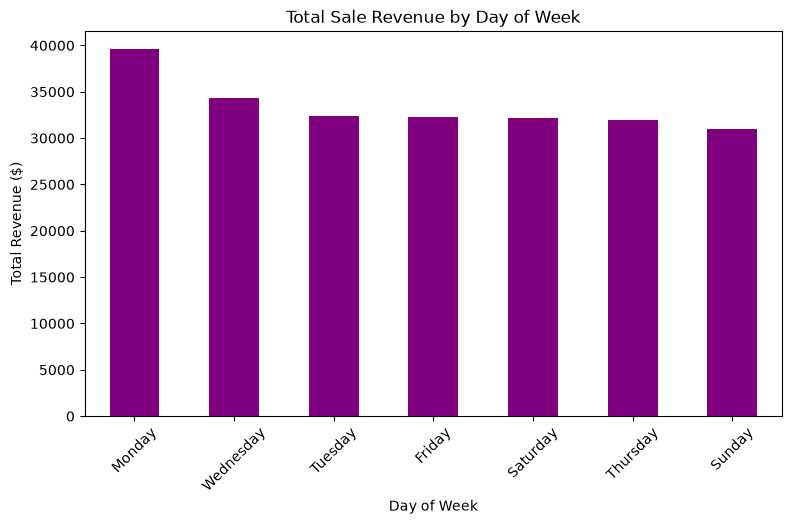

transaction_day
Monday       39563.74
Wednesday    34374.03
Tuesday      32371.81
Friday       32304.55
Saturday     32138.85
Thursday     31902.82
Sunday       31014.75
Name: line_item_amount, dtype: float64


In [55]:
# Are there better or worse days/times in terms of sales?
day_revenue = coffee_df.groupby('transaction_day')['line_item_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
day_revenue.plot(kind='bar', color='purple')
plt.title('Total Sale Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()

# Write your findings
print(day_revenue)

> 👉 **Write Your Findings Here**: 
-- -

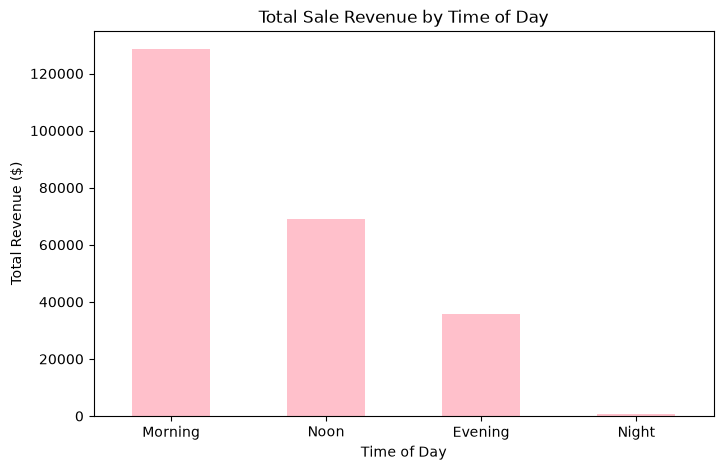

time_category
Morning    128462.37
Noon        68893.76
Evening     35714.29
Night         600.13
Name: line_item_amount, dtype: float64


In [56]:
# Are there better or worse days/times in terms of sales?
time_revenue = coffee_df.groupby('time_category')['line_item_amount'].sum().reindex(['Morning', 'Noon', 'Evening', 'Night'])


plt.figure(figsize=(8, 5))
time_revenue.plot(kind='bar', color='pink')
plt.title('Total Sale Revenue by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0)
plt.show()

# Write your findings
print(time_revenue)

> 👉 **Write Your Findings Here**: 
-- -

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

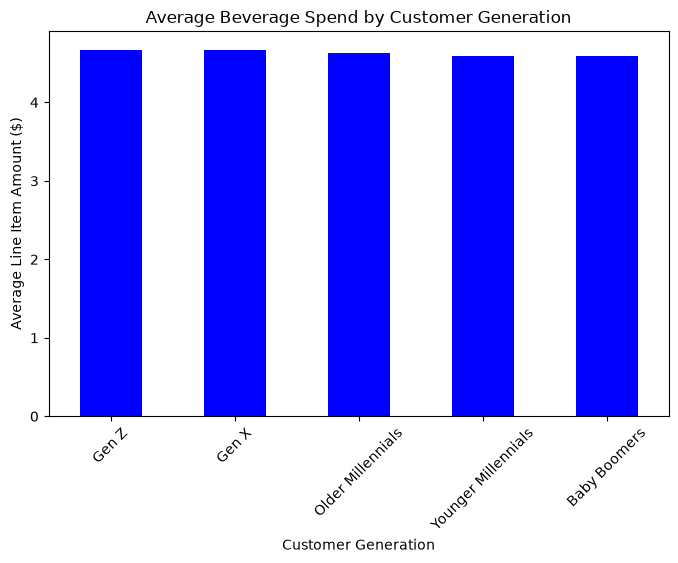

customer_generation
Gen Z                  4.672979
Gen X                  4.668764
Older Millennials      4.631068
Younger Millennials    4.593273
Baby Boomers           4.588123
Name: line_item_amount, dtype: float64


In [57]:
# Does customers’ willingness to pay for Beverages vary by generation?

beverages_df = coffee_df[coffee_df['product_group'] == 'Beverages']
beverages_by_generation = beverages_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
beverages_by_generation.plot(kind='bar', color='blue')
plt.title('Average Beverage Spend by Customer Generation')
plt.xlabel('Customer Generation')
plt.ylabel('Average Line Item Amount ($)')
plt.xticks(rotation=45)
plt.show()

# Write your findings
print(beverages_by_generation)

> 👉 **Write Your Findings Here**: 
-- -

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

In [59]:
# Do customers who have been customers longer tend to spend more?

coffee_df['tenure_days'] = (coffee_df['transaction_date'] - coffee_df['customer_since']).dt.days
coffee_df[['customer_since', 'transaction_date', 'tenure_days']].head()


,customer_since,transaction_date,tenure_days
0,2018-06-19,2019-04-01,286.0
1,2017-03-03,2019-04-01,759.0
2,2019-01-14,2019-04-01,77.0
3,2017-08-11,2019-04-01,598.0
4,2018-05-06,2019-04-01,330.0


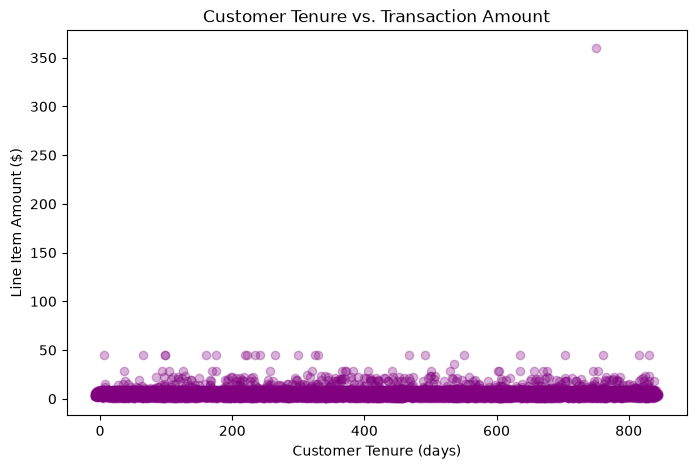

In [60]:
tenure_analysis = coffee_df.dropna(subset=['tenure_days'])

plt.figure(figsize=(8, 5))
plt.scatter(tenure_analysis['tenure_days'], tenure_analysis['line_item_amount'], alpha=0.3, color='purple')
plt.title('Customer Tenure vs. Transaction Amount')
plt.xlabel('Customer Tenure (days)')
plt.ylabel('Line Item Amount ($)')
plt.show()

correlation = tenure_analysis['tenure_days'].corr(tenure_analysis['line_item_amount'])
